# Client personality analysis
Author: David Moncivais | August 4 2026 | Data: [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)

## Introduction

### Objective
The objective of this project is to use the available data — a list of customers with different attributes — and cluster the information to summarize customer segments. A secondary objective, as with previous projects, is to use it as a practice exercise for data presentation, feature engineering, model selection, hyperparameter tuning, and the interpretation of results through data visualization.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.  It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers. 

### The data
The data is a dataset of 2240 rows of individual customers, where each feature column is part of a simplified group of characteristics for each customer. The groups are: People, Products, Promotion, and Place. The dataset description give use the next glossary of the columns needed to look at for the experiment:
- People
    - ID: Customer's unique identifier
    - Year_Birth: Customer's birth year
    - Education: Customer's education level
    - Marital_Status: Customer's marital status
    - Income: Customer's yearly household income
    - Kidhome: Number of children in customer's household
    - Teenhome: Number of teenagers in customer's household
    - Dt_Customer: Date of customer's enrollment with the company
    - Recency: Number of days since customer's last purchase
    - Complain: 1 if the customer complained in the last 2 years, 0 otherwise
- Products
    - MntWines: Amount spent on wine in last 2 years
    - MntFruits: Amount spent on fruits in last 2 years
    - MntMeatProducts: Amount spent on meat in last 2 years
    - MntFishProducts: Amount spent on fish in last 2 years
    - MntSweetProducts: Amount spent on sweets in last 2 years
    - MntGoldProds: Amount spent on gold in last 2 years
- Promotion
    - NumDealsPurchases: Number of purchases made with a discount
    - AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - Response: 1 if customer accepted the offer in the last campaign, 0 otherwise
- Place
    - NumWebPurchases: Number of purchases made through the company’s website
    - NumCatalogPurchases: Number of purchases made using a catalogue
    - NumStorePurchases: Number of purchases made directly in stores
    - NumWebVisitsMonth: Number of visits to company’s website in the last month

## Data exploration

Before starting, here are the libraries needed for the data exploration portion of this project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import math

Next is the reading of the data and capturing the features previously mentioned in the introduction. There are more features that are not mentioned but still exist in the data, but since the same page doesn't give me an explanation of what they are, I decided not to take them into account and stick with what I know. Since this dataset doesn't come with information on how many data entries it has, I decided to add a little line to check this.

In [2]:
base_columns = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Complain', 'MntWines', 'MntFruits',
                'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
                'AcceptedCmp5', 'Response', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
df = pd.read_csv('./Data/marketing_campaign.csv', sep='\t')[base_columns]
print('Number of columns: ' + str(len(base_columns)) + '\nNumber of data entries: ' + str(len(df['ID'])))

Number of columns: 26
Number of data entries: 2240


We can see here that the number of columns it gives us is 26 in total, and the total number of data entries is 2240 — a little low, but let's try to make it work to continue this project. Next it's a showcase of how each column is presented in the dataset, next the decription of this one and finally some info about each feature:

In [3]:
for i in range(3):
    display(df[base_columns[i*9:(i*9)+9]].head(5))

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,26,0
4,5324,1981,PhD,Married,58293.0,1,0,94,0


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2
0,635,88,546,172,88,88,3,0,0
1,11,1,6,2,1,6,2,0,0
2,426,49,127,111,21,42,1,0,0
3,11,4,20,10,3,5,2,0,0
4,173,43,118,46,27,15,5,0,0


,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0,0,0,1,8,10,4,7
1,0,0,0,0,1,1,2,5
2,0,0,0,0,8,2,10,4
3,0,0,0,0,2,0,4,6
4,0,0,0,0,5,3,6,5


In [4]:
df_describe = df.describe()
col = df_describe.columns
for i in range(3):
    display(df_describe[col[i*8:(i*8)+8]])

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,Complain,MntWines
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,0.009375,303.935714
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,0.096391,336.597393
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,0.000000,23.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,0.000000,173.500000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,0.000000,504.250000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1.000000,1493.000000


,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,0.064286,0.013393
std,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,0.245316,0.114976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,0.000000,0.000000
50%,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,0.000000,0.000000
75%,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,0.000000,0.000000
max,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,1.000000,1.000000


,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,0.072768,0.074554,0.072768,0.149107,4.084821,2.662054,5.790179,5.316518
std,0.259813,0.262728,0.259813,0.356274,2.778714,2.923101,3.250958,2.426645
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,3.000000
50%,0.000000,0.000000,0.000000,0.000000,4.000000,2.000000,5.000000,6.000000
75%,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,8.000000,7.000000
max,1.000000,1.000000,1.000000,1.000000,27.000000,28.000000,13.000000,20.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Recency              2240 non-null   int64  
 8   Complain             2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

First, we can see that some features are boolean in nature, like whether there are kids or teens at home, whether they have ever complained, or in what campaign the client accepted an offer. We also have a very general view of the purchase history of each client, showing the number of articles purchased for each category. The number of articles bought can range from not buying a single one to buying 1725 or 1493, depending on the type of article. Finally, we can observe which purchase method performs better. In this case, in-store purchases win with an average of about 5.79 purchases per customer, followed by web purchases (\~4.08) and catalog purchases (\~2.66). Store purchases also show the widest range, reaching up to 13 purchases, compared to 27 for web and 28 for catalog — meaning that while store is the most consistent method, a few customers show unusually high activity through web and catalog purchases.

After that table we have another one for seeing if any of the features presented have null entries. In this case one does, 'Income' has 2216 non-null values out of 2240 lines of data. Let's see what percentage is missing:

In [6]:
df[['Income']].isnull().mean() * 100

Income    1.071429
dtype: float64

1% isn't much, let's add code to fill those incomes with the median of the column based on the education group of each customer, just so it doesn't skew our analysis:

In [7]:
df['Income'] = df.groupby('Education')['Income'].transform(lambda x: x.fillna(x.median()))
df[['Income']].isnull().mean() * 100

Income    0.0
dtype: float64

Once we have that under control, as a matter of personal preference I'll change one variable and group several others. The Year_Birth feature will be substituted for one called 'Age', since it's easier to read and understand. The group of variables 'AcceptedCmp' and 'Response' will be substituted into one single feature called 'Campaign', since all variables are of boolean type, indicating whether the client accepted an offer in one of the 6 campaigns. It seems easier to create a feature called 'Campaign' and store the number (1 to 6) depending on which campaign an offer was accepted, and 0 if the client hasn't accepted anything.

In [8]:
i = 0
r_camp = []
r_age = []
for row in df.itertuples():
    try: r_camp.append(row[18:24].index(1)+1)
    except: r_camp.append(0)
    r_age.append(2026 - int(row[2]))
df['campaign'] = r_camp
df['Age'] = r_age
df = df.drop(['Year_Birth'], axis=1)
df = df.drop(['AcceptedCmp'+str(i) for i in range(1,6)]+['Response'], axis=1)
df.head(3)

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,campaign,Age
0,5524,Graduation,Single,58138.0,0,0,58,0,635,88,...,172,88,88,3,8,10,4,7,5,69
1,2174,Graduation,Single,46344.0,1,1,38,0,11,1,...,2,1,6,2,1,1,2,5,6,72
2,4141,Graduation,Together,71613.0,0,0,26,0,426,49,...,111,21,42,1,8,2,10,4,0,61


Here we can see that the last function worked, and we now have the 2 new features to reduce the other 7.

Next, I developed 2 functions to help with the next section of the data exploration. The basic idea is to graph the clients' personal data against customer characteristics (amount of each product bought and how they bought it). Since most of it will be repetition of code, it's better to put it all in functions so it's easier for the reader later on. Both will present percentages of a total. The only difference is that the first one works with ranges of numbers as well as categorical labels for x, while the second one works for displaying (if applicable) a larger, more detailed set without ranges — showing every single unique value of x.

In [9]:
def distribution_graph_simple(df: pd.DataFrame, x_label: str = '', y_label: list[str] = ['']):
    df_pct_avg = 0
    df_pct = df[y_label].div(df[y_label].sum(axis=1), axis=0) * 100
    if pd.api.types.is_numeric_dtype(df[x_label]):
        options = {1: 5, 2: 50, 3: 500, 4: 5000, 5:25000}
        inter = options[math.floor(math.log10(max(df[x_label])))]
        b_min = int(min(df[x_label]))
        b_max = max(df[x_label]) % inter
        b_max = int(max(df[x_label]) if b_max == 0 else max(df[x_label]) + (inter - b_max))
        lst_bin = [i for i in range(b_min, b_max+1, inter)]
        bins = pd.cut(df[x_label], bins=lst_bin, right=False)
        df_pct_avg = df_pct.groupby(bins).mean().reset_index()
    else:
        df_pct_avg = df_pct.groupby(df[x_label]).mean().reset_index()

    bottom = None
    plt.figure(figsize=(13,8))
    for col in y_label:
        bars = plt.bar(df_pct_avg[x_label].astype(str), df_pct_avg[col], bottom=bottom, label=col)
        for bar, val, b in zip(bars, df_pct_avg[col], bottom if bottom is not None else [0]*len(bars)):
            plt.text(bar.get_x()+bar.get_width()/2, b+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8)
        if bottom is None:
            bottom = df_pct_avg[col].copy()
        else:
            bottom += df_pct_avg[col]
    
    plt.yticks([i for i in range(5,101,5)])
    
    plt.xlabel('Ranges of ' + x_label)
    plt.ylabel('% of total amount')
    if x_label == 'Age':
        plt.title('According to ' + x_label + ', What is what clients want? (Ranges)')
    else:
        plt.title('According to ' + x_label + ', What is what clients want?')
        
    plt.legend()
    plt.show()

def distribution_graph_detailed(df: pd.DataFrame(), x_label: str = '', y_label: list[str] = ['']):
    df_pct = df[y_label].div(df[y_label].sum(axis=1), axis=0) * 100
    df_pct_avg = df_pct.groupby(df[x_label]).mean().reset_index()

    bottom = None
    plt.figure(figsize=(13,8))
    for col in y_label:
        plt.bar(df_pct_avg[x_label], df_pct_avg[col], bottom=bottom, label=col)
        if bottom is None:
            bottom = df_pct_avg[col].copy()
        else:
            bottom += df_pct_avg[col]
    
    plt.yticks([i for i in range(5,101,5)])
    
    plt.xlabel(x_label)
    plt.ylabel('% of total amount')
    plt.title('According to ' + x_label + ', What is what clients want?')

    plt.legend()
    plt.show()

Here are the unique values of the categorical value presented in this data set. The first one is the education level a client have and the second the marital status of the same one.

In [10]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

From what I could gather, since I only know 'high school diploma', 'Bachelor's', 'Master's', and 'PhD', Graduation is the same as a Bachelor's, Basic is like a high school diploma, and 2nd Cycle is something like a postgraduate degree in the European education system.

In [11]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In this one, apart from the first 5 that are typical, we have 'Alone', 'Absurd', and 'YOLO', and being that I just happen to be leaving my 'Young' phase behind, I could infer the following:
- Alone means that the person simply doesn't see themself in a relationship (just like single, but with more emphasis on the "single" part).
- Absurd is either a way of saying that this person sees the question as trying to put them inside a box they don't feel they fit in, or that they don't fully understand their current situationship.
- And 'YOLO' I think can only be described as a way of describing a person who isn't going to be tied down to anyone.

Since everyone lives a different life, and it wouldn't be fair to assume that people of the same age are all doing the same things, in this next part I'll explore how different each age range is from the others, starting by classifying everyone in the data into these ranges.

In [12]:
year_inter = [i for i in range(min(df['Age']), max(df['Age']) + 1, 5)]
new_col = []
df_aux = df[['Age', 'Education', 'Marital_Status']].sort_values('Age')
df_aux['AgeRange'] = False
for y_inter in year_inter:
    mask = df_aux['Age'].between(y_inter,y_inter+5, inclusive='left')
    df_aux.loc[mask, 'AgeRange'] = '[' + str(y_inter) + '-' + str(y_inter+5) + ')'
df_aux.head(3)

C:\Users\david\AppData\Local\Temp\ipykernel_32648\1086522446.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[30-35)' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_aux.loc[mask, 'AgeRange'] = '[' + str(y_inter) + '-' + str(y_inter+5) + ')'


,Age,Education,Marital_Status,AgeRange
46,30,2n Cycle,Married,[30-35)
1170,30,Basic,Married,[30-35)
2213,31,2n Cycle,Single,[30-35)


Before grouping the values by age range, let’s first determine the exact number of people in each age range.

In [13]:
df_aux[['AgeRange','Education']].groupby('AgeRange', as_index = False, sort=False).count().rename(columns = {'Education':'Count'}) 

,AgeRange,Count
0,[30-35),28
1,[35-40),119
2,[40-45),199
3,[45-50),260
4,[50-55),394
5,[55-60),330
6,[60-65),255
7,[65-70),232
8,[70-75),241
9,[75-80),139


Here we can see that most people are between 35 and 80 years old, with a particularly large number of people between 50 and 55. When analyzing each age group by education and marital status, this will help us get actual numbers instead of only percentages of the total.

Now that we can see how these ranges are represented, as well as the boundaries of each range and how many people are in each one, I’ll create two new DataFrames. One will be used to group education levels by age range, while the other will do the same for marital status. If a group does not contain one of the variables within a category, the code will add it with a percentage of 0.

In [14]:
totals = df_aux.groupby('AgeRange')['Education'].transform('count')
df_aux['%Education'] = (df_aux.groupby(['AgeRange','Education'], sort=False)['Marital_Status'].transform('count') / totals) * 100
df_aux['%Marital_Status'] = (df_aux.groupby(['AgeRange','Marital_Status'], sort=False)['Education'].transform('count') / totals) * 100
df_age_edu = df_aux.pivot_table(index='AgeRange', columns='Education', values='%Education', aggfunc='first', fill_value= 0, sort=False)
df_age_ms = df_aux.pivot_table(index='AgeRange', columns='Marital_Status', values='%Marital_Status', aggfunc='first', fill_value= 0, sort=False)
display(df_age_edu, df_age_ms)

Education,2n Cycle,Basic,Graduation,Master,PhD
AgeRange,,,,,
[30-35),14.285714,17.857143,60.714286,7.142857,0.000000
[35-40),13.445378,6.722689,57.142857,10.084034,12.605042
[40-45),11.055276,3.517588,52.261307,14.572864,18.592965
[45-50),16.153846,5.000000,56.153846,11.153846,11.538462
[50-55),10.152284,2.284264,46.954315,15.989848,24.619289
[55-60),5.454545,0.303030,52.424242,19.393939,22.424242
[60-65),6.666667,1.568627,48.627451,16.862745,26.274510
[65-70),9.051724,1.724138,50.431034,16.379310,22.413793
[70-75),6.639004,0.414938,54.356846,20.331950,18.257261


Marital_Status,Married,Single,Together,Absurd,Divorced,Alone,Widow,YOLO
AgeRange,,,,,,,,
[30-35),21.428571,57.142857,17.857143,3.571429,0.000000,0.000000,0.000000,0.000000
[35-40),36.134454,42.016807,15.966387,0.000000,5.042017,0.840336,0.000000,0.000000
[40-45),44.723618,27.638191,25.628141,0.000000,2.010050,0.000000,0.000000,0.000000
[45-50),41.538462,21.923077,28.076923,0.000000,8.076923,0.000000,0.384615,0.000000
[50-55),45.177665,17.766497,23.350254,0.000000,11.421320,0.253807,1.522843,0.507614
[55-60),36.969697,18.787879,25.454545,0.000000,15.151515,0.000000,3.636364,0.000000
[60-65),35.294118,23.529412,23.529412,0.000000,13.725490,0.000000,3.921569,0.000000
[65-70),34.482759,16.810345,31.896552,0.431034,10.775862,0.431034,5.172414,0.000000
[70-75),34.439834,19.087137,29.045643,0.000000,12.863071,0.000000,4.564315,0.000000


Now that we have both of our tables ready, we can create two graphs to compare marital status and education level across different age ranges.

Text(0.5, 0, 'Ranges of age')

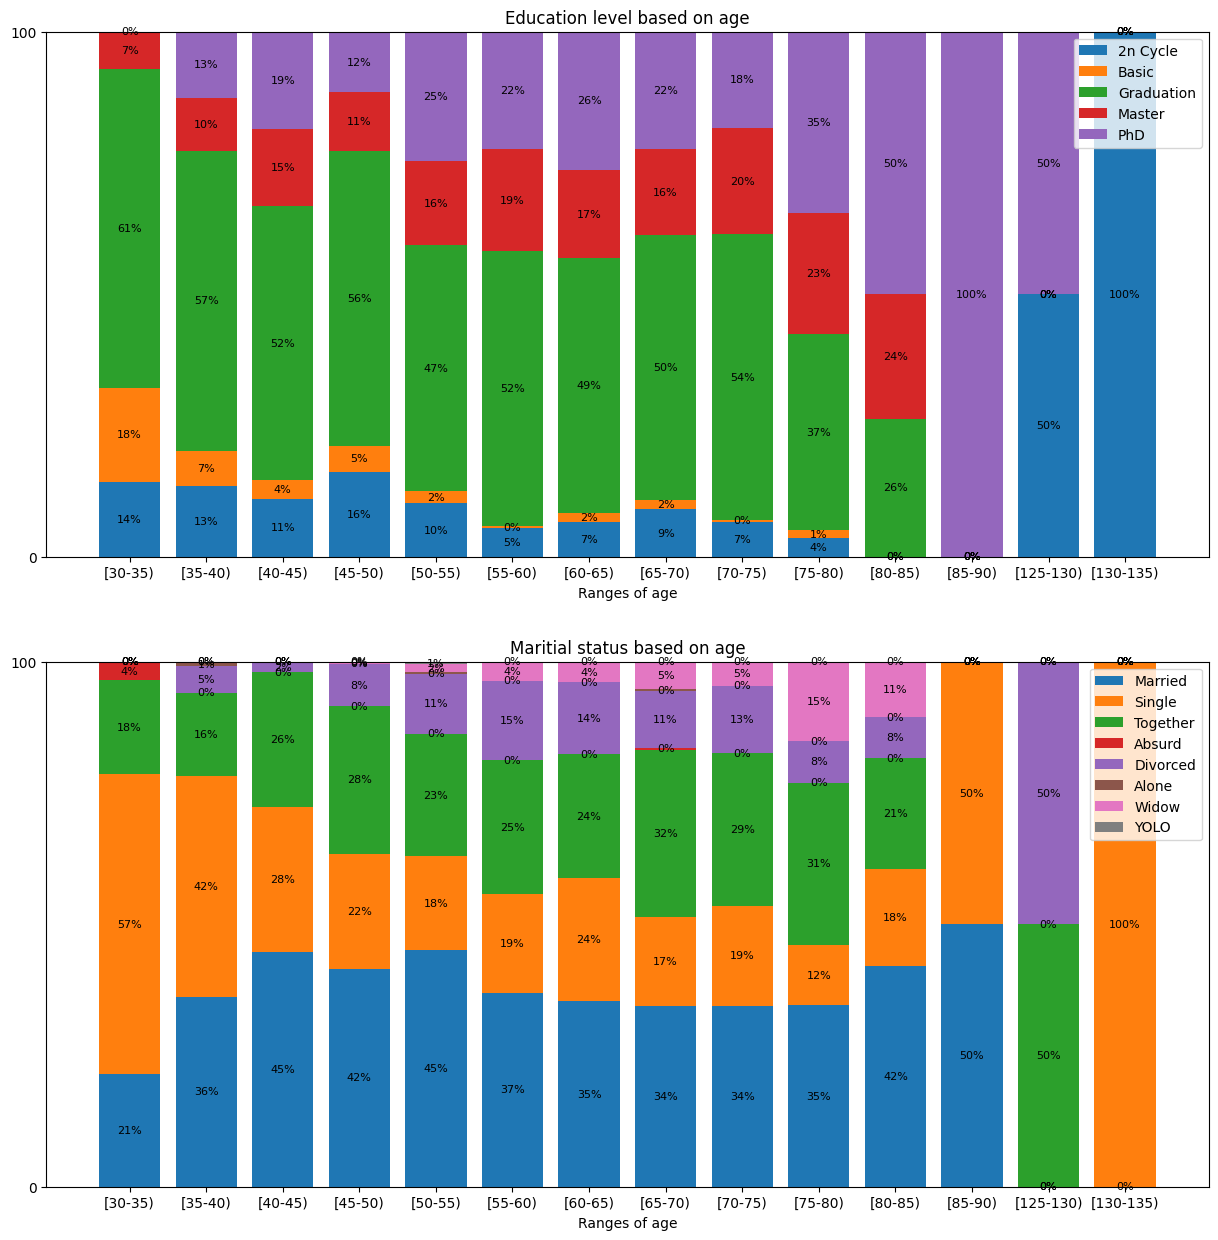

In [15]:
fig, ax = plt.subplots(ncols = 1, nrows = 2)
fig.set_figwidth(15)
fig.set_figheight(15)
ax = ax.flatten()
bottom = None
for col in df_age_edu.columns:
    bars = ax[0].bar(df_age_edu.index, df_age_edu[col], bottom=bottom, label=col)
    for bar, val, b in zip(bars, df_age_edu[col], bottom if bottom is not None else [0]*len(bars)):
        ax[0].text(bar.get_x()+bar.get_width()/2, b+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8)
    if bottom is None:
        bottom = df_age_edu[col].copy()
    else:
        bottom += df_age_edu[col]
ax[0].legend()
ax[0].set_title('Education level based on age')
ax[0].set_yticks([0,100])
ax[0].set_xlabel('Ranges of age')



bottom = None
for col in df_age_ms.columns:
    bars = ax[1].bar(df_age_ms.index, df_age_ms[col], bottom=bottom, label=col)
    for bar, val, b in zip(bars, df_age_ms[col], bottom if bottom is not None else [0]*len(bars)):
        ax[1].text(bar.get_x()+bar.get_width()/2, b+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8)
    if bottom is None:
        bottom = df_age_ms[col].copy()
    else:
        bottom += df_age_ms[col]
ax[1].legend()
ax[1].set_title('Maritial status based on age')
ax[1].set_yticks([0,100])
ax[1].set_xlabel('Ranges of age')


Now we can bring together all the information we have gathered about the clients and make comparisons. For example, we can see that for most of the age groups (from 35 to 80), the majority of people are graduates, as this category has the highest percentage in each group. Therefore, the total number of graduates across these age groups is:
$$
\begin{aligned}
&(0.57 \times 119) + (0.52 \times 199) + (0.56 \times 260) + (0.47 \times 394) + (0.52 \times 330) + (0.49 \times 255) + (0.50 \times 232) + (0.54 \times 241) + (0.37 \times 139) \\
&= 68 + 103 + 146 + 185 + 172 + 125 + 116 + 130 + 51 \\
&= 1096
\end{aligned}
$$
So around 1096 from those groups combined are graduates. During the process of doing this we also know how many people in each group have graduated — for example, we know that for the 35 to 40 year olds we have around 68 people who graduated. If we want to see the marital status of those, we need to see how those 119 fit into each status:
$$
\begin{aligned}
Alone: (119 \times 0.00840336) = 1 \\
Divorced: (119 \times 0.05042017) = 6 \\
Together: (119 \times 0.15966387) = 19 \\
Single: (119 \times 0.42016807) = 50 \\
Married: (119 \times 0.36134454) = 43 \\
\end{aligned}
$$
Roughly speaking, by these results we can guess that if we pick someone at random from the group of graduated people, chances are they will be either single or married.

Now we start analyzing both parts of the data combined (clients and store info), starting with ages and income against groups of products and where they buy them from. First, I'll filter the data to take only people who are less than 100 years old. The reason is that I see them as outliers in the data, since the last person who isn't above 100 is around 80 years old, making it a great leap between ages. Also, there are only about two people who will not be taken into account based on this filter.

In [16]:
df_sort = df.sort_values(by = 'Age')[df['Age'] <100]

C:\Users\david\AppData\Local\Temp\ipykernel_32648\644072408.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sort = df.sort_values(by = 'Age')[df['Age'] <100]


Next, I'll use the functions previously developed to be able to plug in the columns I want and the x value needed — right now it'll be "Age".

C:\Users\david\AppData\Local\Temp\ipykernel_32648\341027084.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


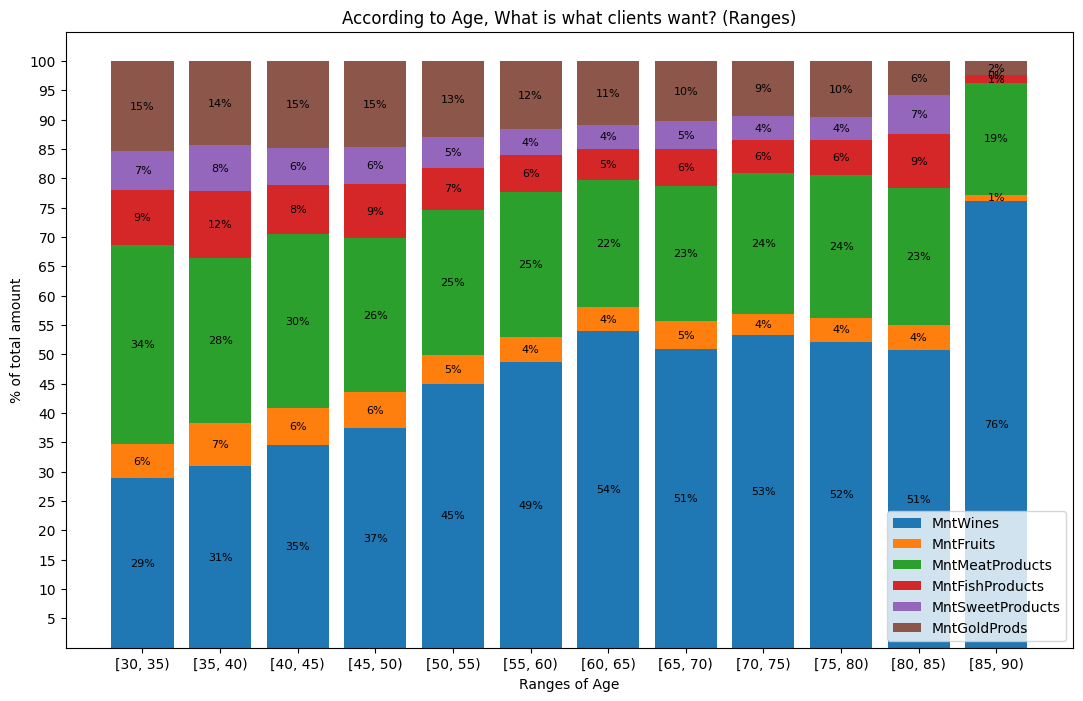

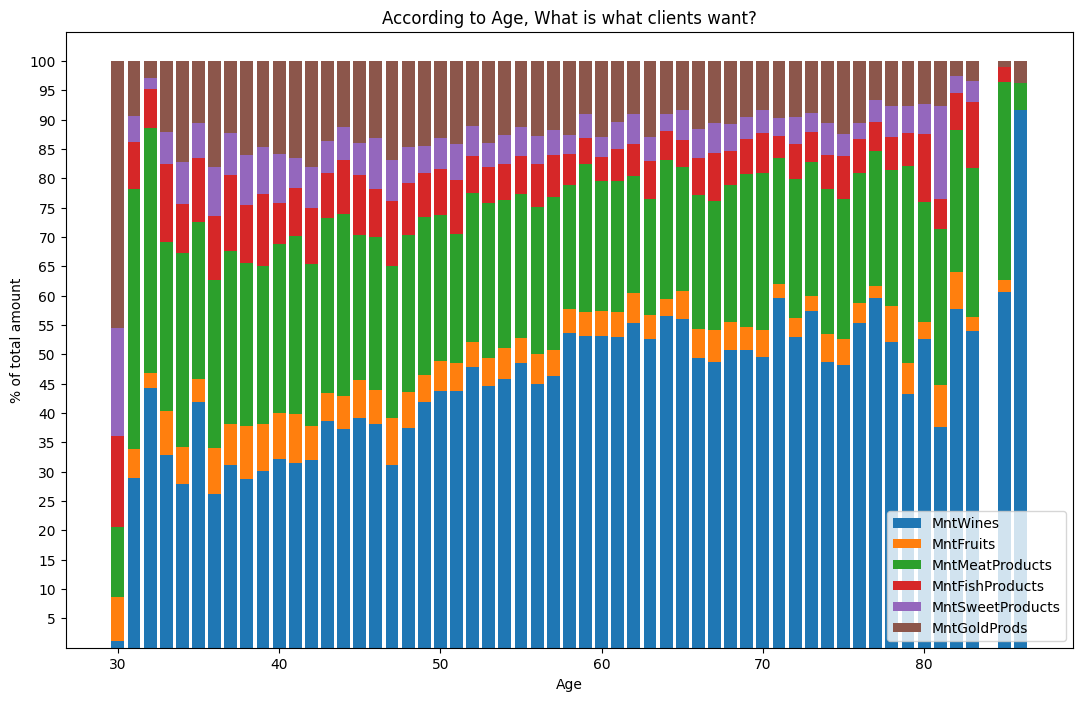

In [17]:
cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
distribution_graph_simple(df_sort, 'Age', cols)
distribution_graph_detailed(df_sort, 'Age', cols)

Interesting enough, we can see that for the youngest group, the largest number of items purchased are of the meat kind, whereas for the oldest group, the leading category is wine items. In both the grouped and the continuous graphs, we can see the sudden changes in "priorities". For the first group, the priorities went: first place for meat with 34%, second place for wine with 29%, and third for gold with 15%. For the oldest group, their priorities went: first for wine with 76%, meat with 19%, and gold with 2%.

Next, I'll do the same analysis but with income ranges, and only the ranges, since having a continuous graph of this resulted in too much information cramped into a graph.

C:\Users\david\AppData\Local\Temp\ipykernel_32648\341027084.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


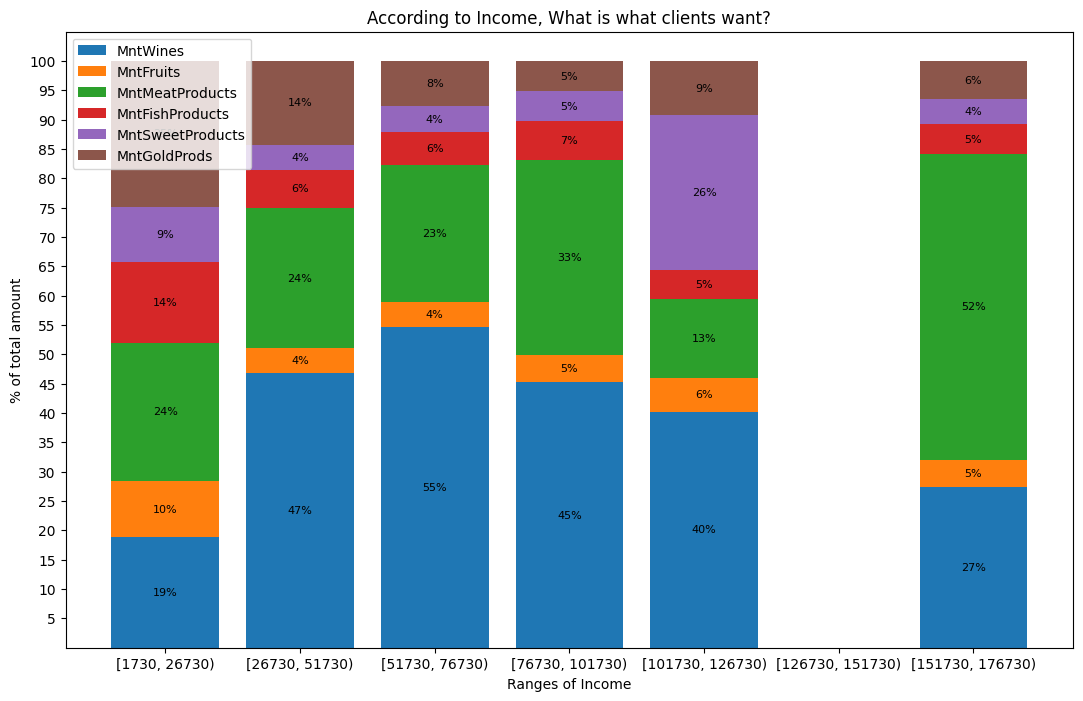

In [18]:
distribution_graph_simple(df_sort, 'Income', cols)

This results got more interesting, it looks like people with low income tend to spend more on gold that in any type of food product, while people within the highest income group are more inclined to buy meat items in first place and wines in seconds.

Next, the columns to be analyzed with age are the ones showing the preference in the way each age group wants to buy their respective products: Web, catalog, and in-person/storefront.

C:\Users\david\AppData\Local\Temp\ipykernel_32648\341027084.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


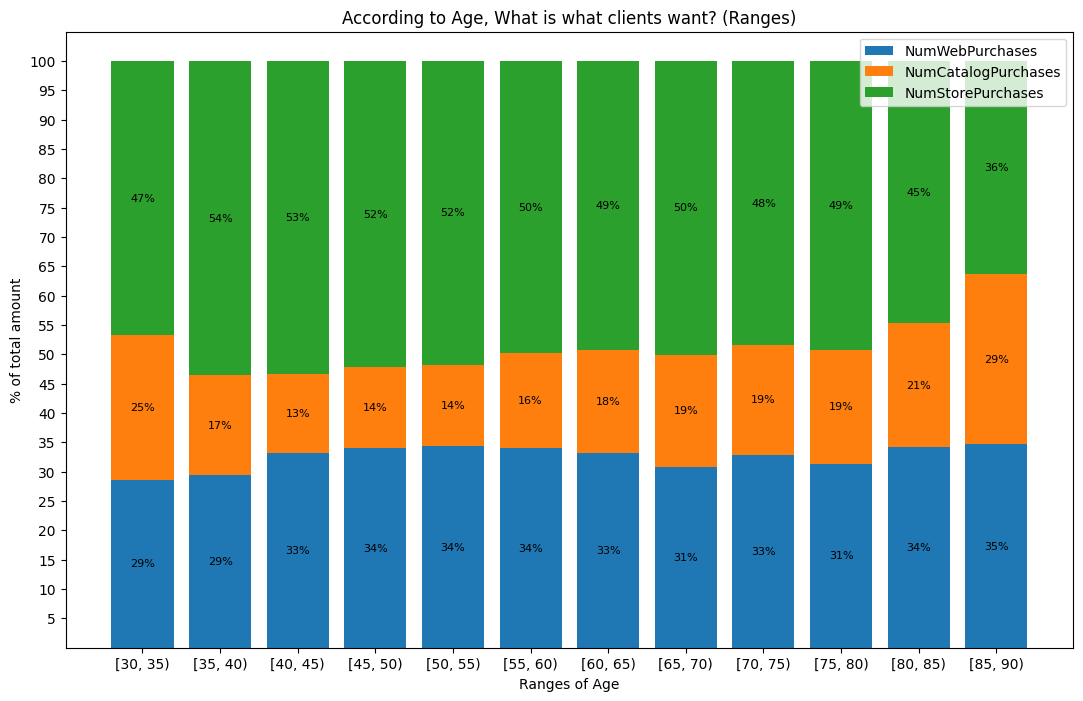

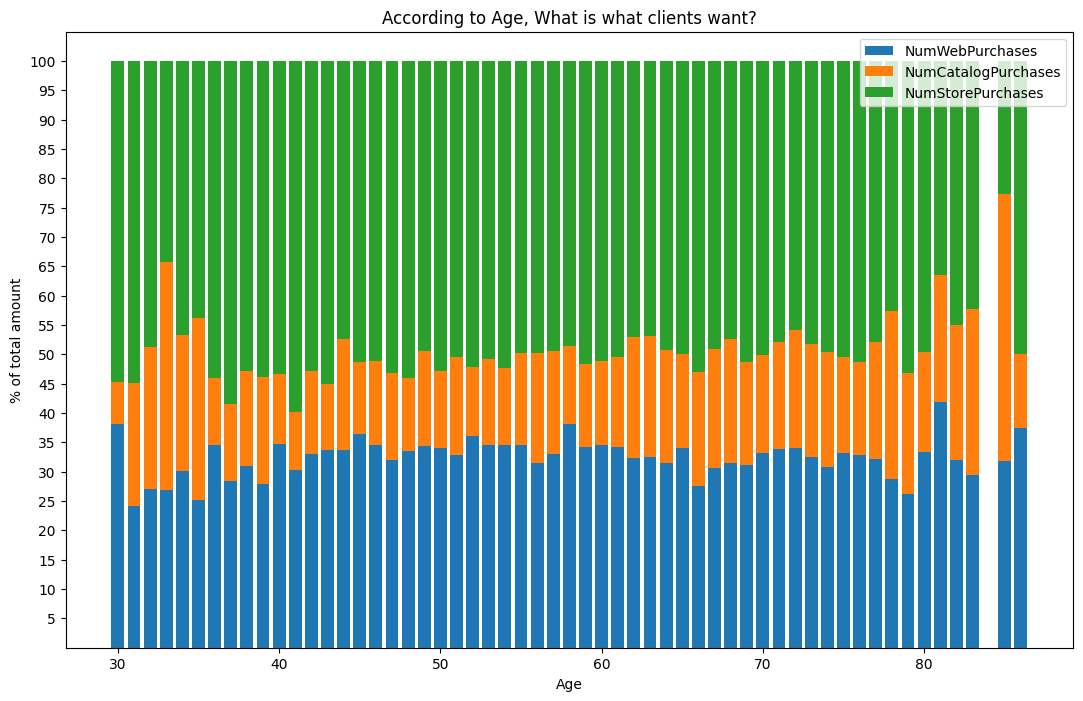

In [19]:
cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
distribution_graph_simple(df_sort, 'Age', cols)
distribution_graph_detailed(df_sort, 'Age', cols)

First, we see that catalog is the least used form of purchasing in this store, which makes sense since before online shopping, buying through catalog was the modus operandi for people who preferred not to go to the store, and there wasn't any other alternative either. With the rise of online stores like Amazon, eBay, Etsy, etc., people find it easier to get what they want through web pages instead of picking up a phone and telling someone what they want. We can see in the continuous graph that 2 age groups show a large number of catalog purchases, and they're far apart from each other. The highest one, at 85 years old, could be people who just never got used to using a computer to buy products online. The second highest, however, is at 33 years old, which raises the question: why do people at that age show this abnormal number of catalog purchases?

OAnother thing to notice is that although online shopping has turned into such a profitable market by making it easier to get what you want without leaving your house, people are still more interested in going into the store and getting it themselves. Personally, I think the reason behind this is simply that by doing so, it takes less time to get what you need, and you don't rely on someone else who won't have the same objective view or the same criteria as you when picking the product you're looking for.

Next will use the same columns but look into the ranges of income.

C:\Users\david\AppData\Local\Temp\ipykernel_32648\341027084.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


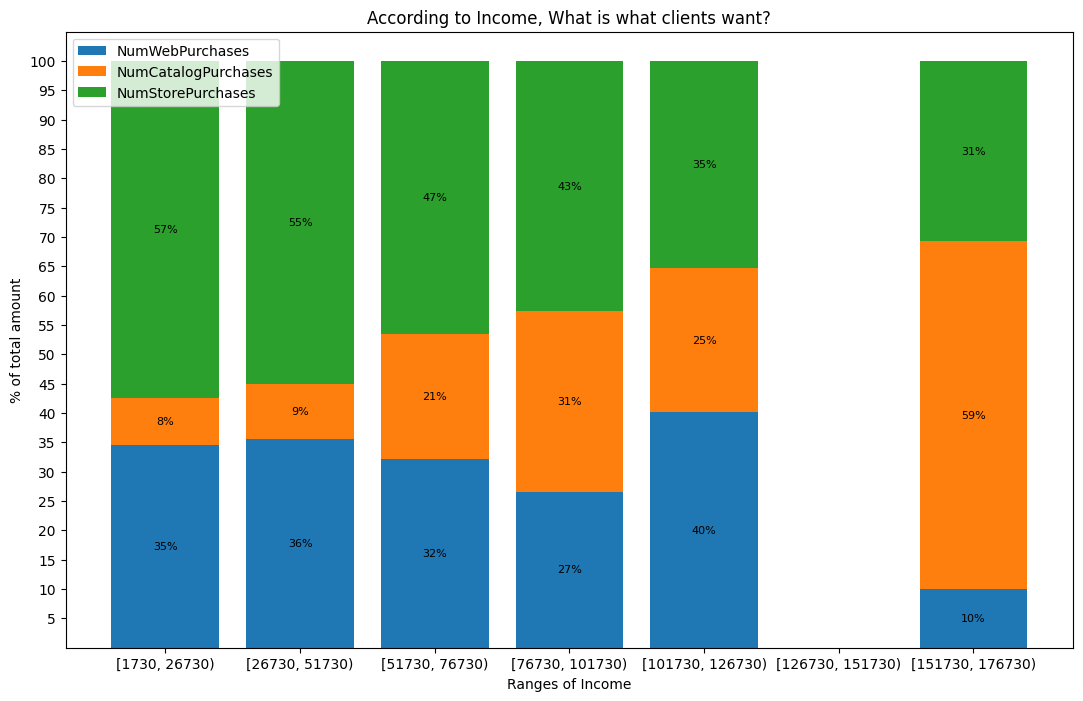

In [20]:
distribution_graph_simple(df_sort, 'Income', cols)

Here we can see something interesting: as income ranges increase, the number of people who buy through catalogs increases as well. Personally, it seems kind of odd. I mean, when we compare people with lower income — where catalog purchases represent only 8% of that group's total — it suggests they are probably younger people who aren't used to, or don't know about, catalog purchases, which is why store and web are the leading categories in that group. Meanwhile, people with an income above 150,000 are likely older people who know some of the advantages of buying through catalog.

Next, I'll be looking at how different education levels and marital status relate to the type of product bought in this store.

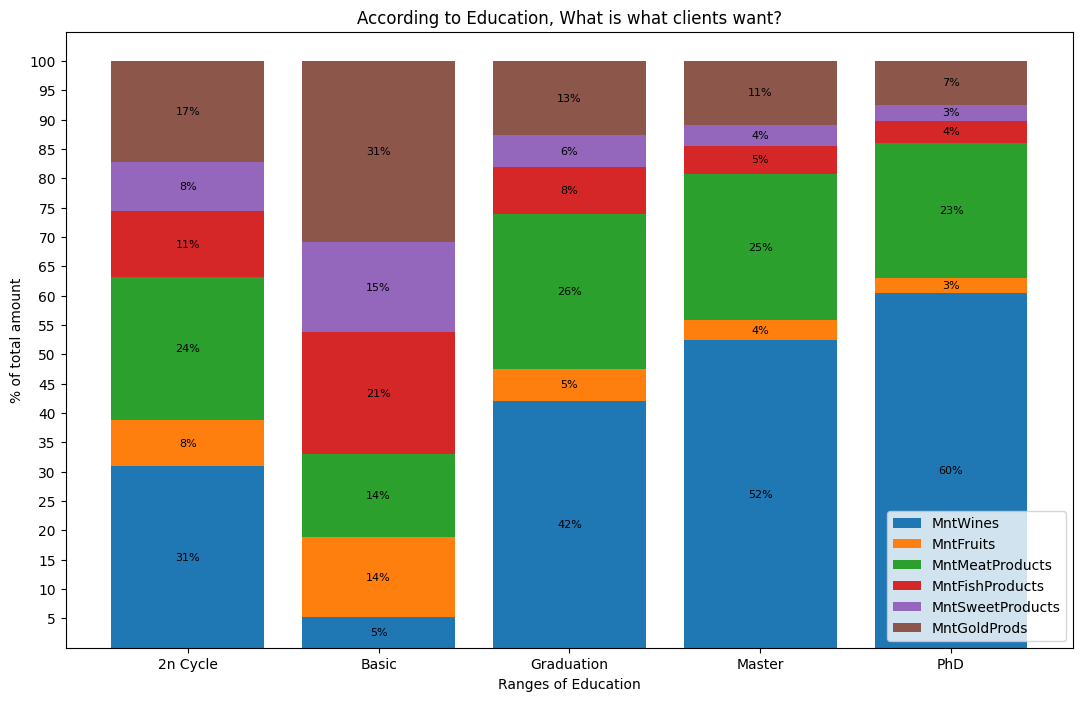

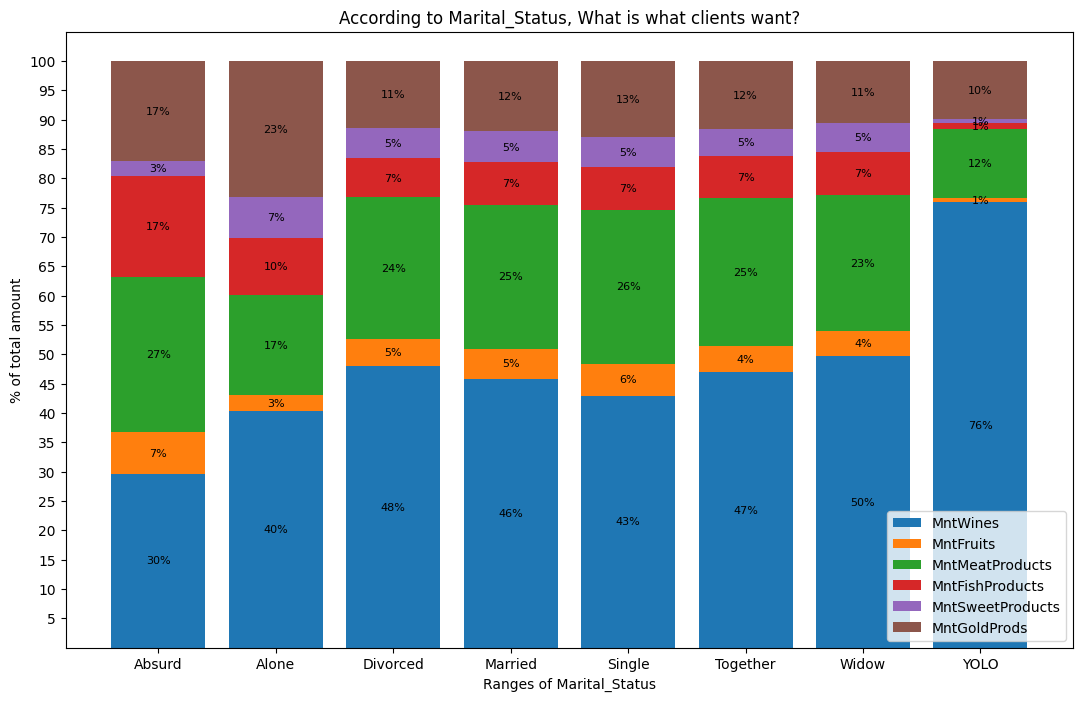

In [21]:
cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
distribution_graph_simple(df, 'Education', cols)
distribution_graph_simple(df_sort, 'Marital_Status', cols)

The graphs tell us that people with a basic level of education are the most balanced in terms of what they bought, having the categories more evenly distributed within their group. Another thing worth noting is that all groups keep a modest flow of wine purchases, and roughly the same percentage — around 24% — of meat products across the groups. Something that is curious to me is that, besides the 2nd Cycle group, the higher the education level, the more wine is purchased. I wonder what the relation might be.

Next is the marital status graph. I'll be focusing on divorced, married, single, together, and widow, since alone, absurd, and YOLO turned out to be the minorities in the data, having around 2 to 4 people in their group, respectively. Surprisingly, all of these 5 categories maintain a similar distribution across most product types, with some of them just changing 1 or 2% between groups.

Next, I'll be moving on to the way of purchase based on the same categories as the ones before.

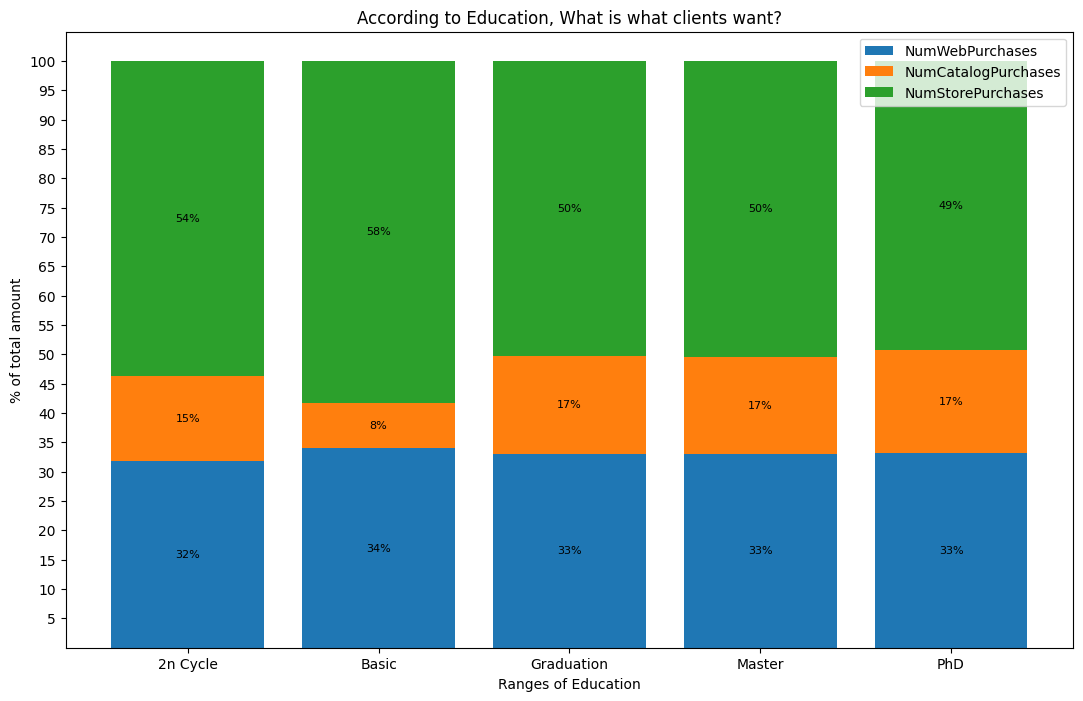

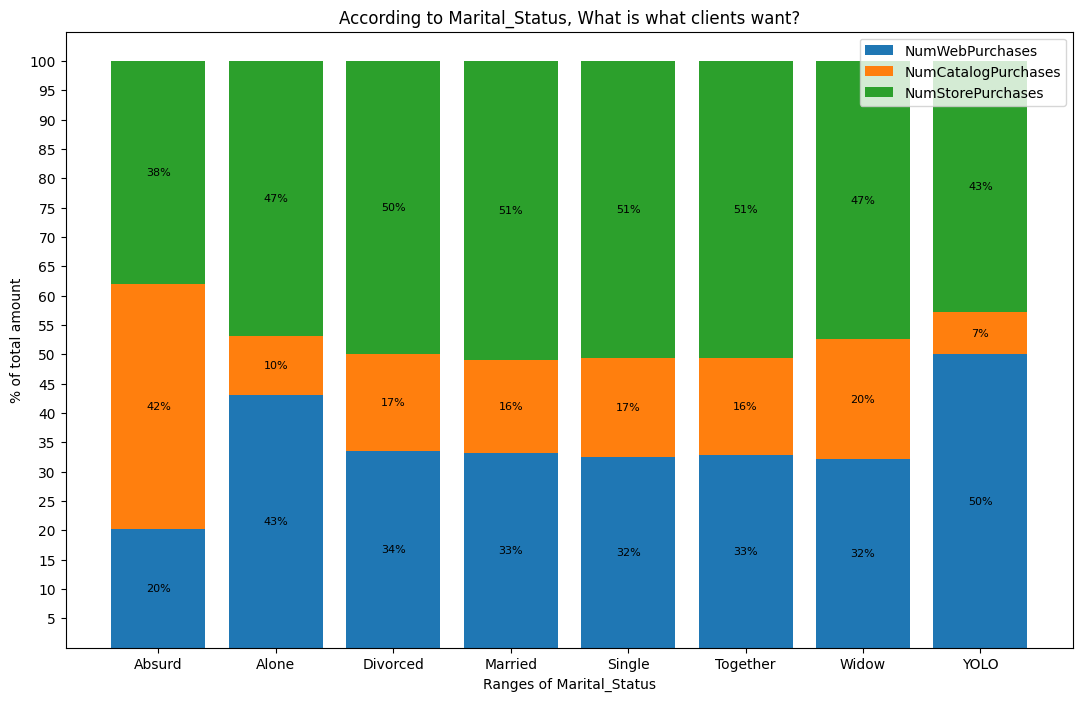

In [22]:
cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
distribution_graph_simple(df_sort, 'Education', cols)
distribution_graph_simple(df_sort, 'Marital_Status', cols)

In this first graph we can see that education levels maintain a similar distribution across all categories, with the exception of the basic level, where apparently people like to buy more things through the store than the other two options. In the second graph (again, not considering absurd, alone, and YOLO), all 5 categories share the same distribution. The only one that moves a little away from the distribution is the people who are widowed, where they tend to consume more through catalogs than through the store.

## Model
### Data preparation

In [23]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'Complain', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'campaign', 'Age'],
      dtype='object')

In [24]:
print(df.shape)
df['NumDependents'] = df['Kidhome'] + df['Teenhome']
df = df[[ 'Education', 'Marital_Status', 'Income', 'NumDependents', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'campaign', 'Age']][(df['Age'] < 100) & (~df['Marital_Status'].isin(['Alone', 'Absurd', 'YOLO']))]
print(df.shape)
df.head(3)

(2240, 21)
(2230, 16)


,Education,Marital_Status,Income,NumDependents,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,campaign,Age
0,Graduation,Single,58138.0,0,635,88,546,172,88,88,3,8,10,4,5,69
1,Graduation,Single,46344.0,2,11,1,6,2,1,6,2,1,1,2,6,72
2,Graduation,Together,71613.0,0,426,49,127,111,21,42,1,8,2,10,0,61


### Model use

In [25]:
from scipy.cluster.vq import kmeans